In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pickle
import os

In [30]:
df = pd.read_csv(r'/media/rahulpatil/10AF-1E07/Nutrition assistance/data/nndb_flat.csv') 

In [31]:
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [33]:
df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


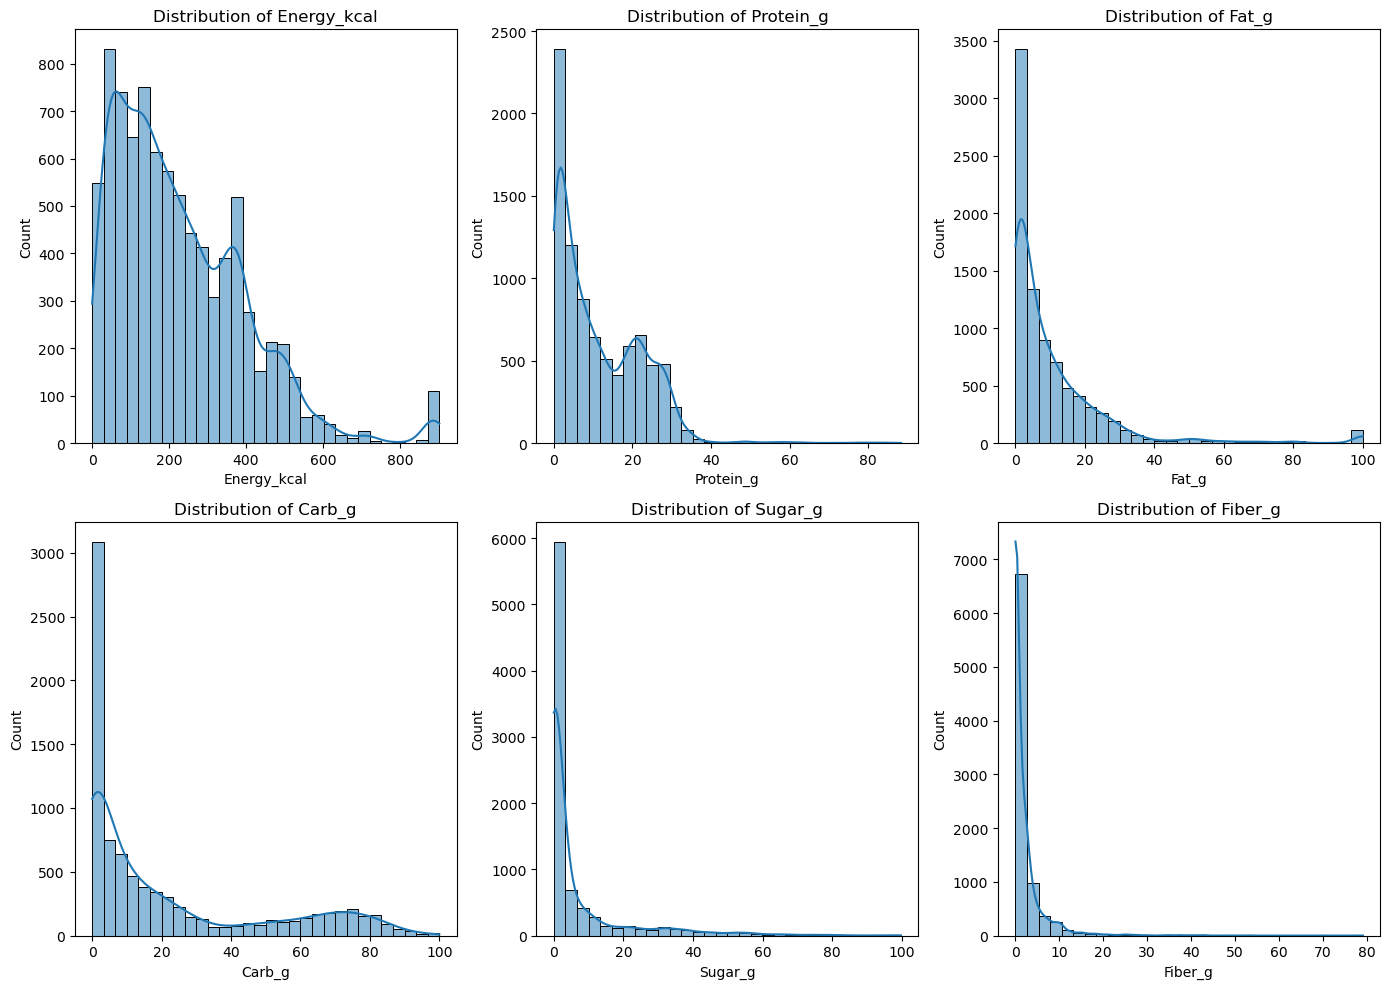

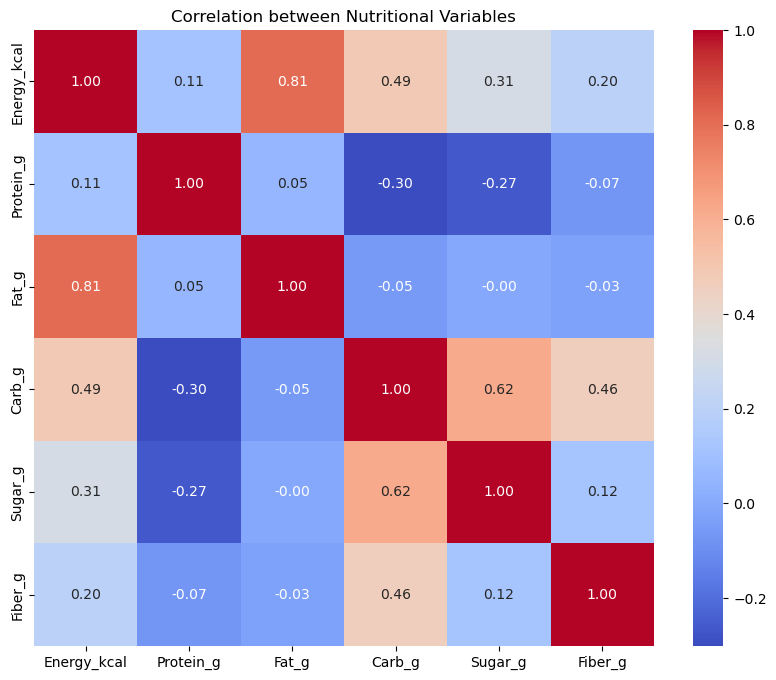

In [34]:
# Summary statistics
summary_stats = df.describe()

# Visualizing distributions for key nutritional variables
nutrients = ['Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g', 'Sugar_g', 'Fiber_g']

plt.figure(figsize=(14, 10))
for i, nutrient in enumerate(nutrients, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[nutrient], kde=True, bins=30)
    plt.title(f'Distribution of {nutrient}')
plt.tight_layout()

# Correlation heatmap for nutrients
plt.figure(figsize=(10, 8))
nutrient_corr = df[nutrients].corr()
sns.heatmap(nutrient_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Nutritional Variables')

plt.show()

In [35]:
# Drop non-numeric and unnecessary columns for regression
data_cleaned = df.drop(columns=['ID', 'ShortDescrip', 'Descrip', 'CommonName', 'MfgName'])

In [36]:
# One-Hot Encoding for 'FoodGroup' and 'ScientificName'
df1 = pd.get_dummies(data_cleaned, columns=['FoodGroup', 'ScientificName'], drop_first=True)

In [37]:
# Fill NaN values if any (optional)
df1.fillna(0, inplace=True)

In [38]:
# Display the first few rows of the transformed dataset
df1.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,ScientificName_Vitis vinifera,ScientificName_Wasabia japonica,ScientificName_X Triticosecale spp.,ScientificName_Xanthosoma sagittifolium,ScientificName_Xiphias gladius L.,ScientificName_Zea mays,ScientificName_Zea mays mays L.,ScientificName_Zingiber officinale,ScientificName_Zizania spp.,ScientificName_Ziziphus jujuba
0,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,False,False,False,False,False,False,False,False,False,False
1,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,False,False,False,False,False,False,False,False,False,False
2,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,False,False,False,False,False,False,False,False,False,False
3,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,False,False,False,False,False,False,False,False,False,False
4,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,False,False,False,False,False,False,False,False,False,False


In [39]:
# Define features (X) and target (y)
X = df1.drop(columns=['Energy_kcal'])
y = df1['Energy_kcal']

In [40]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled.shape, X_test_scaled.shape

((6894, 529), (1724, 529))

In [43]:
# Initialize the models
random_forest = RandomForestRegressor(random_state=42)
xgboost = XGBRegressor(random_state=42)
gradient_boosting = GradientBoostingRegressor(random_state=42)
cat_boost = CatBoostRegressor(random_state=42)

In [44]:
# Train the models
random_forest.fit(X_train_scaled, y_train)
xgboost.fit(X_train_scaled, y_train)
gradient_boosting.fit(X_train_scaled, y_train)
cat_boost.fit(X_train_scaled, y_train)

Learning rate set to 0.055547
0:	learn: 161.3016802	total: 9.76ms	remaining: 9.75s
1:	learn: 153.7500149	total: 17.8ms	remaining: 8.91s
2:	learn: 146.3383850	total: 29.8ms	remaining: 9.9s
3:	learn: 139.7994904	total: 41.5ms	remaining: 10.3s
4:	learn: 133.8297960	total: 52.6ms	remaining: 10.5s
5:	learn: 127.7858622	total: 64.2ms	remaining: 10.6s
6:	learn: 122.0901225	total: 73.2ms	remaining: 10.4s
7:	learn: 116.5452197	total: 88.9ms	remaining: 11s
8:	learn: 111.3679373	total: 97.4ms	remaining: 10.7s
9:	learn: 106.2126024	total: 107ms	remaining: 10.6s
10:	learn: 101.7094359	total: 115ms	remaining: 10.4s
11:	learn: 97.4494079	total: 125ms	remaining: 10.3s
12:	learn: 93.3841566	total: 133ms	remaining: 10.1s
13:	learn: 89.6961502	total: 143ms	remaining: 10.1s
14:	learn: 85.6905968	total: 153ms	remaining: 10.1s
15:	learn: 82.2079424	total: 164ms	remaining: 10.1s
16:	learn: 79.1819471	total: 173ms	remaining: 10s
17:	learn: 75.8683362	total: 184ms	remaining: 10s
18:	learn: 72.7177834	total: 19

In [45]:
# Predictions
rf_preds = random_forest.predict(X_test_scaled)
xgb_preds = xgboost.predict(X_test_scaled)
gb_preds = gradient_boosting.predict(X_test_scaled)
ct_preds = cat_boost.predict(X_test_scaled)

In [46]:
# Calculate MSE and RMSE
rf_mse = mean_squared_error(y_test, rf_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
gb_mse = mean_squared_error(y_test, gb_preds)
ct_mse = mean_squared_error(y_test,ct_preds)

In [47]:
rf_rmse = np.sqrt(rf_mse)
xgb_rmse = np.sqrt(xgb_mse)
gb_rmse = np.sqrt(gb_mse)
ct_rmse = np.sqrt(ct_mse)

In [48]:
# Compile results for comparison
model_comparison = {
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting', 'CatBoost'],
    'MSE': [rf_mse, xgb_mse, gb_mse, ct_mse],
    'RMSE': [rf_rmse, xgb_rmse, gb_rmse, ct_rmse]
}

In [49]:
model_comparison_df = pd.DataFrame(model_comparison)

               Model         MSE       RMSE
0      Random Forest  239.014851  15.460105
1            XGBoost  185.288659  13.612078
2  Gradient Boosting  319.973829  17.887812
3           CatBoost  178.121102  13.346202


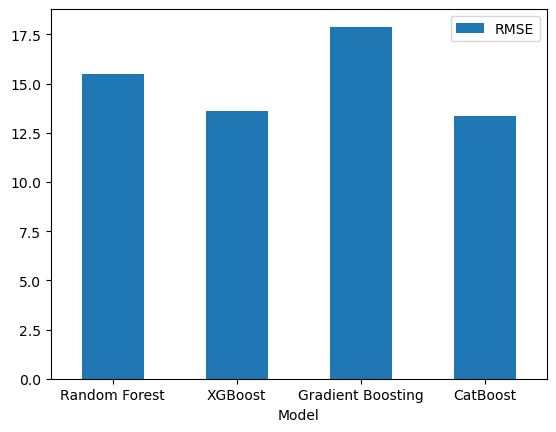

In [50]:
print(model_comparison_df)
ax = model_comparison_df.plot.bar(x='Model', y='RMSE', rot=0)

In [51]:
# Step 3: Save the trained model using Pickle
with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(random_forest, model_file)

print("Model saved successfully.")

Model saved successfully.


In [52]:
# Step 3: Save the trained model using Pickle
with open('XGBoost.pkl', 'wb') as model_file1:
    pickle.dump(xgboost, model_file1)

print("XGBoost Model saved successfully.")

XGBoost Model saved successfully.


In [53]:
# Step 3: Save the trained model using Pickle
with open('gradient_boosting.pkl', 'wb') as model_file2:
    pickle.dump(gradient_boosting, model_file2)

print("Model saved successfully.")

Model saved successfully.


In [54]:
# Step 3: Save the trained model using Pickle
with open('cat_boost.pkl', 'wb') as model_file4:
    pickle.dump(cat_boost, model_file4)

print("Model saved successfully.")

Model saved successfully.


In [55]:
import sklearn
print("Current scikit-learn version:", sklearn.__version__)

Current scikit-learn version: 1.5.2
